# Numerical Simulation Laboratory - Notebook 8

In [100]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

## Exercise 08.1
By using the ansatz $$\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+e^{-\frac{(x+\mu)^2}{2\sigma^2}} $$ for the wave function one can analytically compute
$$\frac{\hat{H} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}=\frac{1}{2\sigma^2}\left\{1-\frac{1}{\sigma^2}\left[x^2+\mu^2-2x\mu\tanh\left(\frac{x\mu}{\sigma^2}\right) \right] \right\}+x^4-\frac{5}{2}x^2\text{,}$$
with $\hbar=1$ and $m=1$.

The expectation value of the ground state energy can be found with a Variational Monte Carlo method by using the metropolis algorithm to sample the square modulus of the trial wave function. This means that the acceptance probability is $$A(x|y)=\min\left[1,\frac{|\Psi_T^{\sigma,\mu}(x)|^2}{|\Psi_T^{\sigma,\mu}(y)|^2}\right]\text{.}$$

The starting values $\mu=0.85$ and $\sigma=0.6$ were chosen by looking at the plot of the ground state wave function obtained by matrix diagonalization. With these starting values the variational algorithm converges to $\langle\hat{H}\rangle_T=-0.435\pm0.003$, which shows that the algorithm is working, since the true ground state energy is $E_\text{GS}\approx-0.46047$ and the values of $\mu$ and $\sigma$ aren't optimized. 

The step size of the Metropolis algorithm was chosen by having an acceptance rate of about $50\%$. The below graph shows how the algorithm with these initial conditions converges to a value of ground state energy, which is different from the one found with matrix diagonalization.

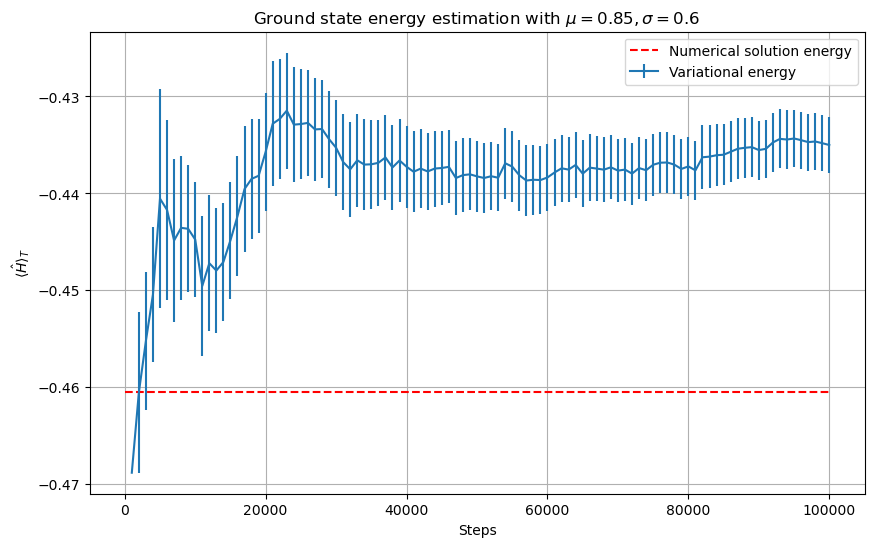

In [101]:
blocks, energy, err = np.loadtxt("../08-Exercises/OUTPUT/output_1.out", unpack=True)

E_gs = -0.460465879692715

fig = plt.figure(figsize=(10,6))
plt.errorbar(blocks*1000, energy, err, label="Variational energy")
plt.hlines(E_gs, 0, blocks[-1]*1000, color="red", linestyle="--", label="Numerical solution energy")
plt.title("Ground state energy estimation with $\\mu=0.85,\\sigma=0.6$")
plt.xlabel("Steps")
plt.ylabel(r"$\langle\hat{H}\rangle_T$")
plt.grid()
plt.legend();

## Exercise 08.2

In [102]:
def psi_T(x, mu, sigma):
    return (np.exp(-(x-mu)**2 / (2 * sigma**2)) + np.exp(-(x+mu)**2 / (2 * sigma**2)))**2

def Vpot(x):
    return (x**2 - 2.5)*x**2

In [103]:
steps, temps, mu, sigma, energies, errors = np.loadtxt("../08-Exercises/OUTPUT/energies_SA.out", unpack=True)
bins, psi, psi_err = np.loadtxt("../08-Exercises/OUTPUT/psi_distribution.out", unpack=True)
blocks, opt_energy, opt_err = np.loadtxt("../08-Exercises/OUTPUT/optimal_energy.out", unpack=True)

opt_mu, opt_sigma = mu[-1], sigma[-1]

x = np.linspace(-4*opt_sigma-opt_mu, 4*opt_sigma+opt_mu, 1000)
analytic = psi_T(x, opt_mu, opt_sigma) / quad(psi_T, -np.inf, np.inf, args=(opt_mu, opt_sigma))[0]

In [104]:
# Calculations for matrix equation
hbar = 1
m = 1
a = 8*opt_sigma
N = 1000 # number of iterations

x_mat = np.linspace(-a/2, a/2, N)
dx = x_mat[1] - x_mat[0] # the step size
V = Vpot(x_mat)
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi_mat = np.linalg.eigh(H)
psi_mat = np.transpose(psi_mat)
psi_mat = psi_mat/np.sqrt(dx)

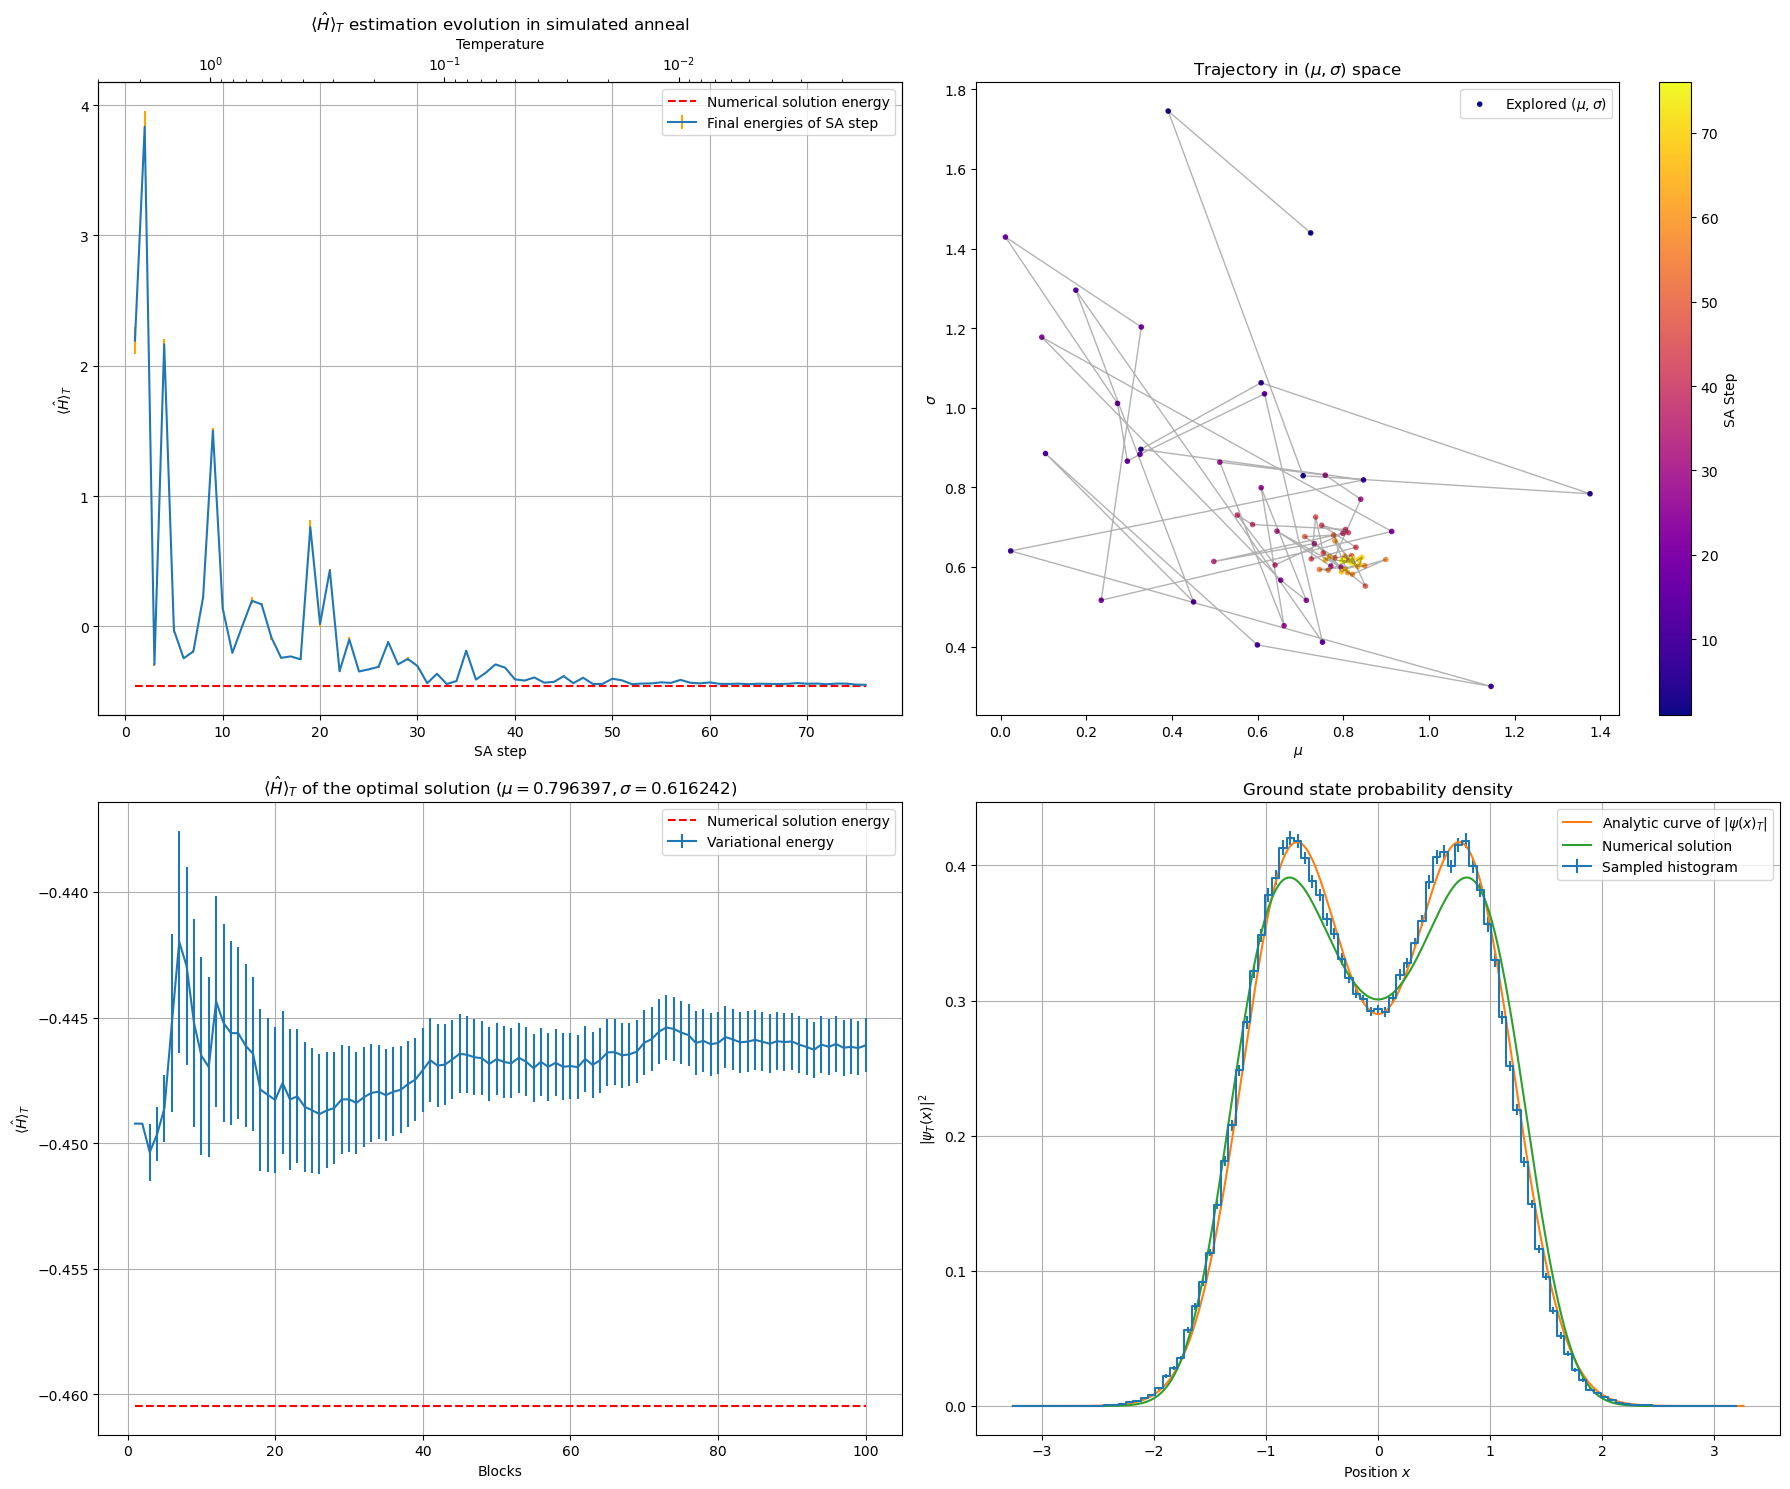

In [106]:
fig, axs = plt.subplots(2, 2, figsize=(18,15))
axs = axs.flatten()

axs[0].errorbar(steps, energies, yerr=errors, ecolor="orange", label="Final energies of SA step")
axs[0].hlines(E_gs, steps[0], steps[-1], color="red", linestyle="--", label="Numerical solution energy")

# Add secondary x-axis with temperatures
ax0_top = axs[0].twiny()
ax0_top.set_xscale("log")
ax0_top.set_xlim(temps[0], temps[-1])
ax0_top.set_xlabel("Temperature")

sc = axs[1].scatter(mu, sigma, marker=".", cmap="plasma", c=steps, label="Explored $(\\mu,\\sigma)$")
axs[1].plot(mu, sigma, color="black", alpha=0.3, linewidth=1, zorder=1)
cbar = fig.colorbar(sc, ax=axs[1])
cbar.set_label("SA Step", fontsize=10)

axs[2].errorbar(blocks, opt_energy, yerr=opt_err, label="Variational energy")
axs[2].hlines(E_gs, blocks[0], blocks[-1], color="red", linestyle="--", label="Numerical solution energy")


axs[3].errorbar(bins, psi, yerr=psi_err, drawstyle="steps-mid", label="Sampled histogram")
axs[3].plot(x, analytic, label="Analytic curve of $|\\psi(x)_T|$")
axs[3].plot(x_mat, psi_mat[0]**2, label="Numerical solution")

x_labels = ["SA step", r"$\mu$", "Blocks", "Position $x$"]
y_labels = [r"$\langle {\hat H} \rangle_T$", r"$\sigma$", r"$\langle {\hat H} \rangle_T$", r"$|\psi_T(x)|^2$"]
titles = [r"$\langle {\hat H} \rangle_T$ estimation evolution in simulated anneal", r"Trajectory in $(\mu,\sigma)$ space", f"$\\langle{{\\hat H}}\\rangle_T$ of the optimal solution $(\\mu={opt_mu},\\sigma={opt_sigma})$", r"Ground state probability density"]

for i, ax in enumerate(axs):
    ax.set_xlabel(x_labels[i])
    ax.set_ylabel(y_labels[i])
    ax.set_title(titles[i])
    ax.legend()
    if (i != 1):
        ax.grid()


plt.tight_layout();

The temperature evolution of the simulated annealing algorithm is a geometric evolution $T_n=T_0(\alpha)^n$ until a minimum temperature $T_\text{min}$ is reached. For each temperature the code performs $N_\text{SA}$ Metropolis moves, in which both $\mu$ and $\sigma$ are changed. The step $\delta_{SA}$ is increased or decreased if the acceptance rate deviates from $50\%$ to have a more efficient exploration of the parameters. The number of MC steps for each evaluation of $\langle\hat{H}\rangle_T$ increases as $N(T)=N_0+100/T$ as the system cools down since a more precise estimation of the energy is needed at lower temperatures. At the end of each SA step (when the temperature is changed after $N_\text{SA}$ Metropolis moves) $\langle\hat{H}\rangle_T$ and its uncertainties are evaluated using data blocking. The final values of $\mu$ and $\sigma$ at the end of the simulated annealing are used to compute the optimal $\langle\hat{H}\rangle_T$ and the histogram of the probability distribution $|\psi(x)_T|^2$. 

In this simulation the starting temperature is $T_0=3$, the cooling rate is $\alpha=0.9$, the minimum temperature is $T_\text{min}=1\times10^{-3}$, the number of moves per SA step is $N_{SA}=200$, and the starting of $\mu=0.85$ and $\sigma=0.6$ are the same of the previous exercise. The histogram is divided in $100$ bins and covers the region $x\in[-\mu-4\sigma,\mu+4\sigma]$.

The optimal solution found by the algorithm is $\mu=0.796397$, $\sigma=0.616242$ and $\langle\hat{H}\rangle_T=-0.4461\pm0.0011$.

The algorithm manages to find a better estimation of the ground state energy than the initial guess, which means that the algorithm is effectively minimizing the variational energy. The figure of the trajectory in the $(\mu,\sigma)$ space shows how a more erratic exploration at high temperatures converges to a small area at low temperature where the optimal parameters lie. The histogram shows how the the algorithm correctly samples the $|\psi(x)_T|^2$ probability distribution when computing the variational energy, since it follows very closely the analytical plot. The Numerical solution on the other hand is clearly different from the other two, which means that the set of parameters do not perfectly approximate the real wave function, as is also clear from the fact that the optimal energy computed by the algorithm is well above the numerical solution (about 14 standard deviations). To find a better solution it would be necessary to compute the energies with more precision end have a finer temperature evolution, which would greatly increase the execution time.

